# Portfolio 2: Are flood-zone homes in Montpelier assessed differently?

Adapted from the Multiple regression notebook authored by Jean-Gabriel Young <jean-gabriel.young@uvm.edu>

In [112]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import cmdstanpy
from cmdstanpy import CmdStanModel

cmdstanpy.set_cmdstan_path(os.path.expanduser("~/cmdstan"))

SEED = 6300
rng = np.random.default_rng(SEED)   # CHANGED: seeded RNG so figures are reproducible

# 1. Data construction and description
All units are in Montpelier. The observational unit is a residential parcel with exactly one home on it. There are 1,509 such parcels, 100 of which are in the flood zone (blue dots in the figure below). A home counts as in the flood zone if any part of its footprint intersects a FEMA Special Flood Hazard Area. We are interested in how assessed value relates to flood zone status and lot size (acres).

As the figure shows, assessed value tends to increase with lot size, though with wide scatter. In-zone homes overlap heavily with out-of-zone homes, but they are concentrated on smaller lots, so a raw comparison between the two groups may partly reflect lot size.

In [113]:
montpelier_data = pd.read_csv("montpelier_parcels.csv")
print(f"Residential parcels, positive assessed value: {len(montpelier_data):,}")
filtered_montpelier_data = montpelier_data[montpelier_data['n_homes'] == 1]
print(f"Exactly one home footprint:                   {len(filtered_montpelier_data):,}")
filtered_montpelier_data = filtered_montpelier_data[filtered_montpelier_data['improvements_value'] > 0]
print(f"improvements_value > 0:                       {len(filtered_montpelier_data):,}")
filtered_montpelier_data = filtered_montpelier_data[filtered_montpelier_data['acres'] > 0].copy()
print(f"acres > 0:                                    {len(filtered_montpelier_data):,}")

filtered_montpelier_data['in_sfha'] = filtered_montpelier_data['in_sfha'].astype(int)   # CHANGED: 0/1 int, not float
filtered_montpelier_data.head()

Residential parcels, positive assessed value: 2,127
Exactly one home footprint:                   1,517
improvements_value > 0:                       1,514
acres > 0:                                    1,509


,listed_real_value,improvements_value,acres,n_homes,in_sfha
0,216500,149400,0.15,1,0
1,476100,381200,0.33,1,0
2,472400,337100,0.40,1,0
7,230500,129900,0.35,1,0
8,280000,208100,0.07,1,0


In [114]:
acre_ticks = ([0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10, 25, 75],
              ['0.05', '0.1', '0.25', '0.5', '1', '2', '5', '10', '25', '75'])
dollar_ticks = ([50_000, 100_000, 200_000, 400_000, 800_000],
                ['$50k', '$100k', '$200k', '$400k', '$800k'])

def viz_scatter(title=None, y_ticks=dollar_ticks, show_data=True):
    """Log value vs. log lot size axes; optionally draw the observed parcels."""
    plt.figure(figsize=(7, 6))
    if show_data:
        out_rows = filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 0]
        in_rows = filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 1]
        plt.scatter(out_rows['log_acres'], out_rows['log_value'], color='lightgrey', edgecolors='k',
                    linewidths=0.5, alpha=0.6, label=f'Outside SFHA (n = {len(out_rows):,})')
        plt.scatter(in_rows['log_acres'], in_rows['log_value'], color='tab:blue', edgecolors='k',
                    linewidths=0.5, label=f'Inside SFHA (n = {len(in_rows):,})')
        plt.legend(title='Flood zone', fontsize=11, title_fontsize=11, loc='lower right')
    plt.xlabel('Lot size (acres, log scale)', fontsize=13)
    plt.ylabel('Assessed value (log scale)', fontsize=13)
    plt.xticks(np.log(acre_ticks[0]), acre_ticks[1])
    plt.yticks(np.log(y_ticks[0]), y_ticks[1])
    plt.tick_params(labelsize=11)
    plt.gca().spines[['top', 'right']].set_visible(False)


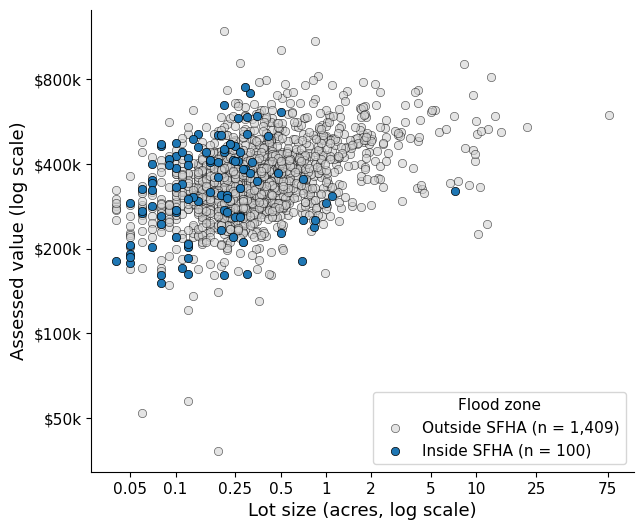

In [115]:
filtered_montpelier_data['log_acres'] = np.log(filtered_montpelier_data['acres'])
filtered_montpelier_data['log_value'] = np.log(filtered_montpelier_data['listed_real_value'])

viz_scatter(title='Assessed value vs. lot size, Montpelier single-home parcels')
plt.savefig('figures/assessed_value_vs_lot_size_montpelier.png', dpi=300)

In [116]:
filtered_montpelier_data.groupby('in_sfha')['log_value'].agg(['count', 'mean', 'std'])

,count,mean,std
in_sfha,,,
0,1409,12.773544,0.310030
1,100,12.695525,0.375086


# 2. Modeling question
**Are homes in Montpelier's FEMA flood hazard area assessed differently from homes outside it, on lots of the same size, and by how much?**

The outcome is assessed home value; the predictors are flood zone status and lot size.


# 3. Model description
We model assessed value on the log scale, so coefficients act multiplicatively on dollars. Lot size enters as log acres, centered at its mean, so the intercept describes a home on a typical (geometric-mean, 0.35-acre) lot.

For each parcel $i = 1, \dots, 1509$: $Y_i$ is the log assessed value, $X_{i1}$ is 1 if the home's footprint intersects a FEMA flood hazard area and 0 otherwise, and $X_{i2}$ is centered log lot size.

$$Y_i\sim\mathrm{Normal}(\mu_i,\sigma) \quad \text{(likelihood)}$$
$$\mu_i = \alpha + \beta_1 X_{i1} + \beta_2 X_{i2}$$
$$\alpha\sim \mathrm{Normal}(12, 0.5) \quad \text{(prior)}$$
$$\beta_j \sim\mathrm{Normal}(0,0.5), \ j = 1, 2 \quad \text{(prior)}$$
$$\sigma \sim\mathrm{Exponential}(3) \quad \text{(prior)}$$

- $\alpha$: expected log value of a home outside the flood zone on a typical lot.
- $\beta_1$: difference in expected log value between homes in and out of the flood zone, on lots of the same size.
- $\beta_2$: change in expected log value per unit of log lot size, i.e. how value scales with lot size.
- $\sigma$: standard deviation of log values around the regression line, assumed the same for homes in and out of the flood zone.

$\alpha, \beta_1, \beta_2$ can take any real value; $\sigma > 0$. In the Stan output, `beta[1]` is $\beta_1$ and `beta[2]` is $\beta_2$. The prior choices are justified in §4.

In [117]:
mean_log_acres = filtered_montpelier_data['log_acres'].mean()
filtered_montpelier_data['x_lot'] = filtered_montpelier_data['log_acres'] - mean_log_acres

X = filtered_montpelier_data[['in_sfha', 'x_lot']].to_numpy()
Y = filtered_montpelier_data['log_value'].to_numpy()
N = len(Y)

multiple_model = CmdStanModel(stan_file="stan_code/multiple_regression.stan")

-3.2188758248682006
9
1071
9


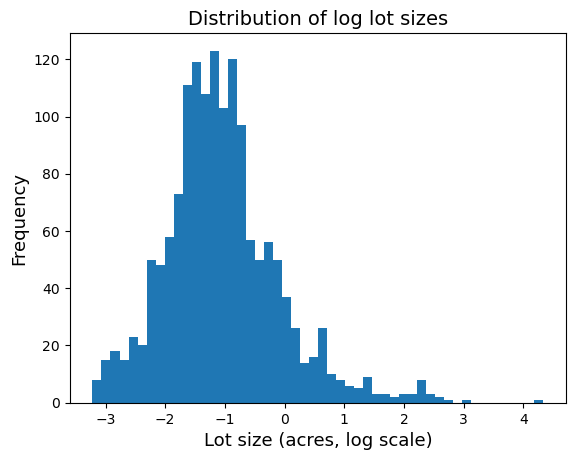

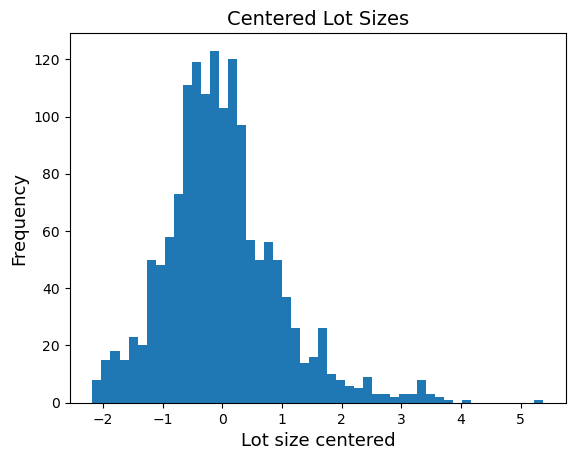

In [118]:
"""
Claude recommended centering the log lot sizes. The checks below are me convincing myself.
From the notes in module 6, "The variable 𝛼 is called the intercept and sets the mean 𝜇𝑖 when 𝑋_i = 0.",
to me centering is the difference between alpha describing a 1 acre lot and alpha describing the average lot size.
There are only 9 houses with 1 acre in the data but more than a 1000 houses with less than 0.5 acres.
I can reason about the assessed value of a more typical house if I center the log lot sizes. I am down.
"""

print(filtered_montpelier_data['log_acres'].min())
print(len(filtered_montpelier_data[filtered_montpelier_data['acres'] == 1]))
print(len(filtered_montpelier_data[filtered_montpelier_data['acres'] <  .5]))

print(len(filtered_montpelier_data[filtered_montpelier_data['log_acres'] ==0]))

plt.hist(filtered_montpelier_data['log_acres'], bins=50)
plt.xlabel('Lot size (acres, log scale)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.title('Distribution of log lot sizes', fontsize=14)
plt.savefig('log_acres_histogram.png')
plt.show()
plt.hist(filtered_montpelier_data['x_lot'], bins=50)
plt.xlabel('Lot size centered', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.title('Centered Lot Sizes', fontsize=14)
plt.savefig('centered_lot_sizes_histogram.png')
plt.show()

# 4. Prior-predictive analysis

In [119]:

candidate_1 = {
    'alpha_mean': 12,
    'alpha_sd': 1.5,
    'beta_sd': 1.5,
    'N': N, 
    'q': X.shape[1], 
    'X': X, 
    'Y': Y, 
    'use_likelihood': 0
}
candidate_1_prior_fit = multiple_model.sample(data=candidate_1, chains=2, seed=SEED)
candidate_1_Y_prior = candidate_1_prior_fit.stan_variable('Y_rep')

candidate_2 = {**candidate_1, 'alpha_sd': 0.5, 'beta_sd': 0.5}
candidate_2_prior_fit = multiple_model.sample(data=candidate_2, chains=2, seed=SEED)
candidate_2_Y_prior = candidate_2_prior_fit.stan_variable('Y_rep')

candidate_1_mu = candidate_1_prior_fit.stan_variable('mu')
candidate_2_mu = candidate_2_prior_fit.stan_variable('mu')

13:54:04 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:54:07 - cmdstanpy - INFO - CmdStan done processing.


13:54:08 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:54:11 - cmdstanpy - INFO - CmdStan done processing.


In [120]:
log_acres = filtered_montpelier_data['log_acres'].to_numpy()
in_zone = filtered_montpelier_data['in_sfha'].to_numpy() == 1

ticks_candidate_1 = ([1, 1e3, 1e6, 1e9, 1e12], ['$1', '$1k', '$1M', '$1B', '$1T'])
ticks_candidate_2 = ([1e3, 1e4, 1e5, 1e6, 1e7], ['$1k', '$10k', '$100k', '$1M', '$10M'])
print(candidate_1_mu.max())
print(candidate_2_mu.max())

39.587721
20.684136


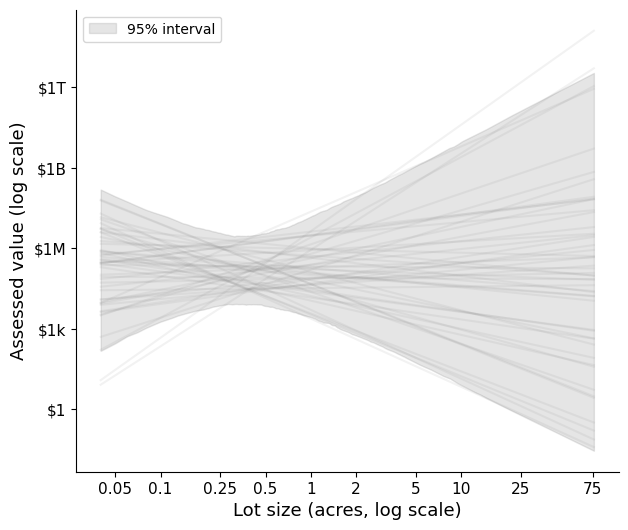

In [121]:
viz_scatter(title='Prior regression lines: candidate 1', y_ticks=ticks_candidate_1, show_data=False)

out_zone = ~in_zone
order = np.argsort(log_acres[out_zone])
for s in rng.choice(len(candidate_1_mu), 50, replace=False):
    plt.plot(log_acres[out_zone][order], candidate_1_mu[s, out_zone][order], color='grey', alpha=0.1)

mu_lower, mu_upper = np.percentile(candidate_1_mu[:, out_zone], [2.5, 97.5], axis=0)
plt.fill_between(log_acres[out_zone][order], mu_lower[order], mu_upper[order],
                 color='grey', alpha=0.2, label='95% interval')
plt.legend(loc='upper left')
plt.savefig('figures/prior_regression_lines_candidate_1.png', dpi=300)


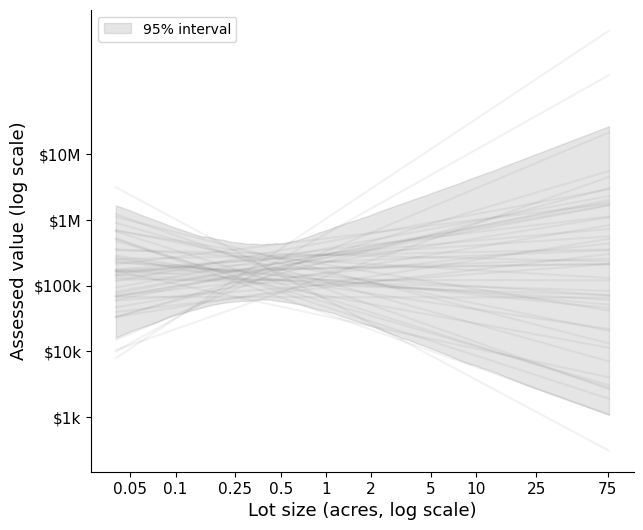

In [122]:
viz_scatter(title='Prior regression lines: candidate 2', y_ticks=ticks_candidate_2, show_data=False)

for s in rng.choice(len(candidate_2_mu), 50, replace=False):
    plt.plot(log_acres[out_zone][order], candidate_2_mu[s, out_zone][order], color='grey', alpha=0.1)

mu_lower, mu_upper = np.percentile(candidate_2_mu[:, out_zone], [2.5, 97.5], axis=0)

plt.fill_between(log_acres[out_zone][order], mu_lower[order], mu_upper[order],
                 color='grey', alpha=0.2, label='95% interval')
plt.legend(loc='upper left')
plt.savefig('figures/prior_regression_lines_candidate_2.png', dpi=300)


In [123]:
for name, fit in [('Candidate 1', candidate_1_prior_fit), ('Candidate 2', candidate_2_prior_fit)]:
    alpha = fit.stan_variable('alpha')
    beta_flood = fit.stan_variable('beta')[:, 0]
    lo, hi = np.exp(np.percentile(alpha, [2.5, 97.5]))
    print(f"{name}: typical ${np.exp(alpha.mean()):,.0f}  (95%: ${lo:,.0f} to ${hi:,.0f})")

Candidate 1: typical $163,055  (95%: $8,382 to $2,917,425)
Candidate 2: typical $162,703  (95%: $60,839 to $428,435)


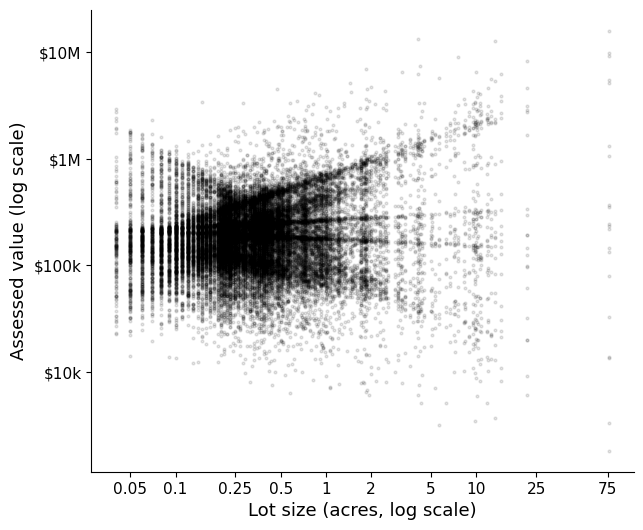

In [124]:
viz_scatter(title='Prior predictive datasets: candidate 2', y_ticks=ticks_candidate_2, show_data=False)
for s in rng.choice(len(candidate_2_Y_prior), 20, replace=False):
    plt.scatter(log_acres, candidate_2_Y_prior[s], color='k', s=4, alpha=0.1)
plt.savefig('figures/prior_predictive_datasets_candidate_2.png', dpi=300)

# 5. Estimation


In [125]:
multiple_data = {**candidate_2, 'use_likelihood': 1}
multiple_fit = multiple_model.sample(data=multiple_data, chains=2, seed=SEED)
print(multiple_fit.diagnose())

13:54:16 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:54:20 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [126]:
multiple_fit.summary(percentiles=(2.5, 50, 97.5)).loc[['alpha', 'beta[1]', 'beta[2]', 'sigma']]

,Mean,MCSE,StdDev,MAD,2.5%,50%,97.5%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,12.766200,0.000164,0.007353,0.007306,12.752100,12.766300,12.780400,2023.89,1635.40,469.580,0.999589
beta[1],0.027938,0.000667,0.029442,0.028862,-0.031467,0.028487,0.087657,1986.76,1353.48,460.965,1.001640
beta[2],0.141202,0.000169,0.007668,0.007447,0.126337,0.141275,0.156344,2074.89,1477.36,481.413,1.001990
sigma,0.285103,0.000119,0.005203,0.005353,0.274938,0.285000,0.295213,1928.49,1319.19,447.446,1.002870


In [136]:
# convert to dollars and percentages
draws = multiple_fit.draws_pd()
baseline = pd.DataFrame({
    'typical home, outside zone ($)': np.exp(draws['alpha']),
    'flood-zone difference (%)':      100 * (np.exp(draws['beta[1]']) - 1),
    'doubling lot size (%)':          100 * (2 ** draws['beta[2]'] - 1),
    'typical scatter factor':         np.exp(draws['sigma']),
})
baseline.quantile([0.025, 0.5, 0.975]).T.round(3)

,0.025,0.500,0.975
"typical home, outside zone ($)",345274.826,350227.597,355202.526
flood-zone difference (%),-3.098,2.890,9.161
doubling lot size (%),9.152,10.288,11.446
typical scatter factor,1.316,1.330,1.343


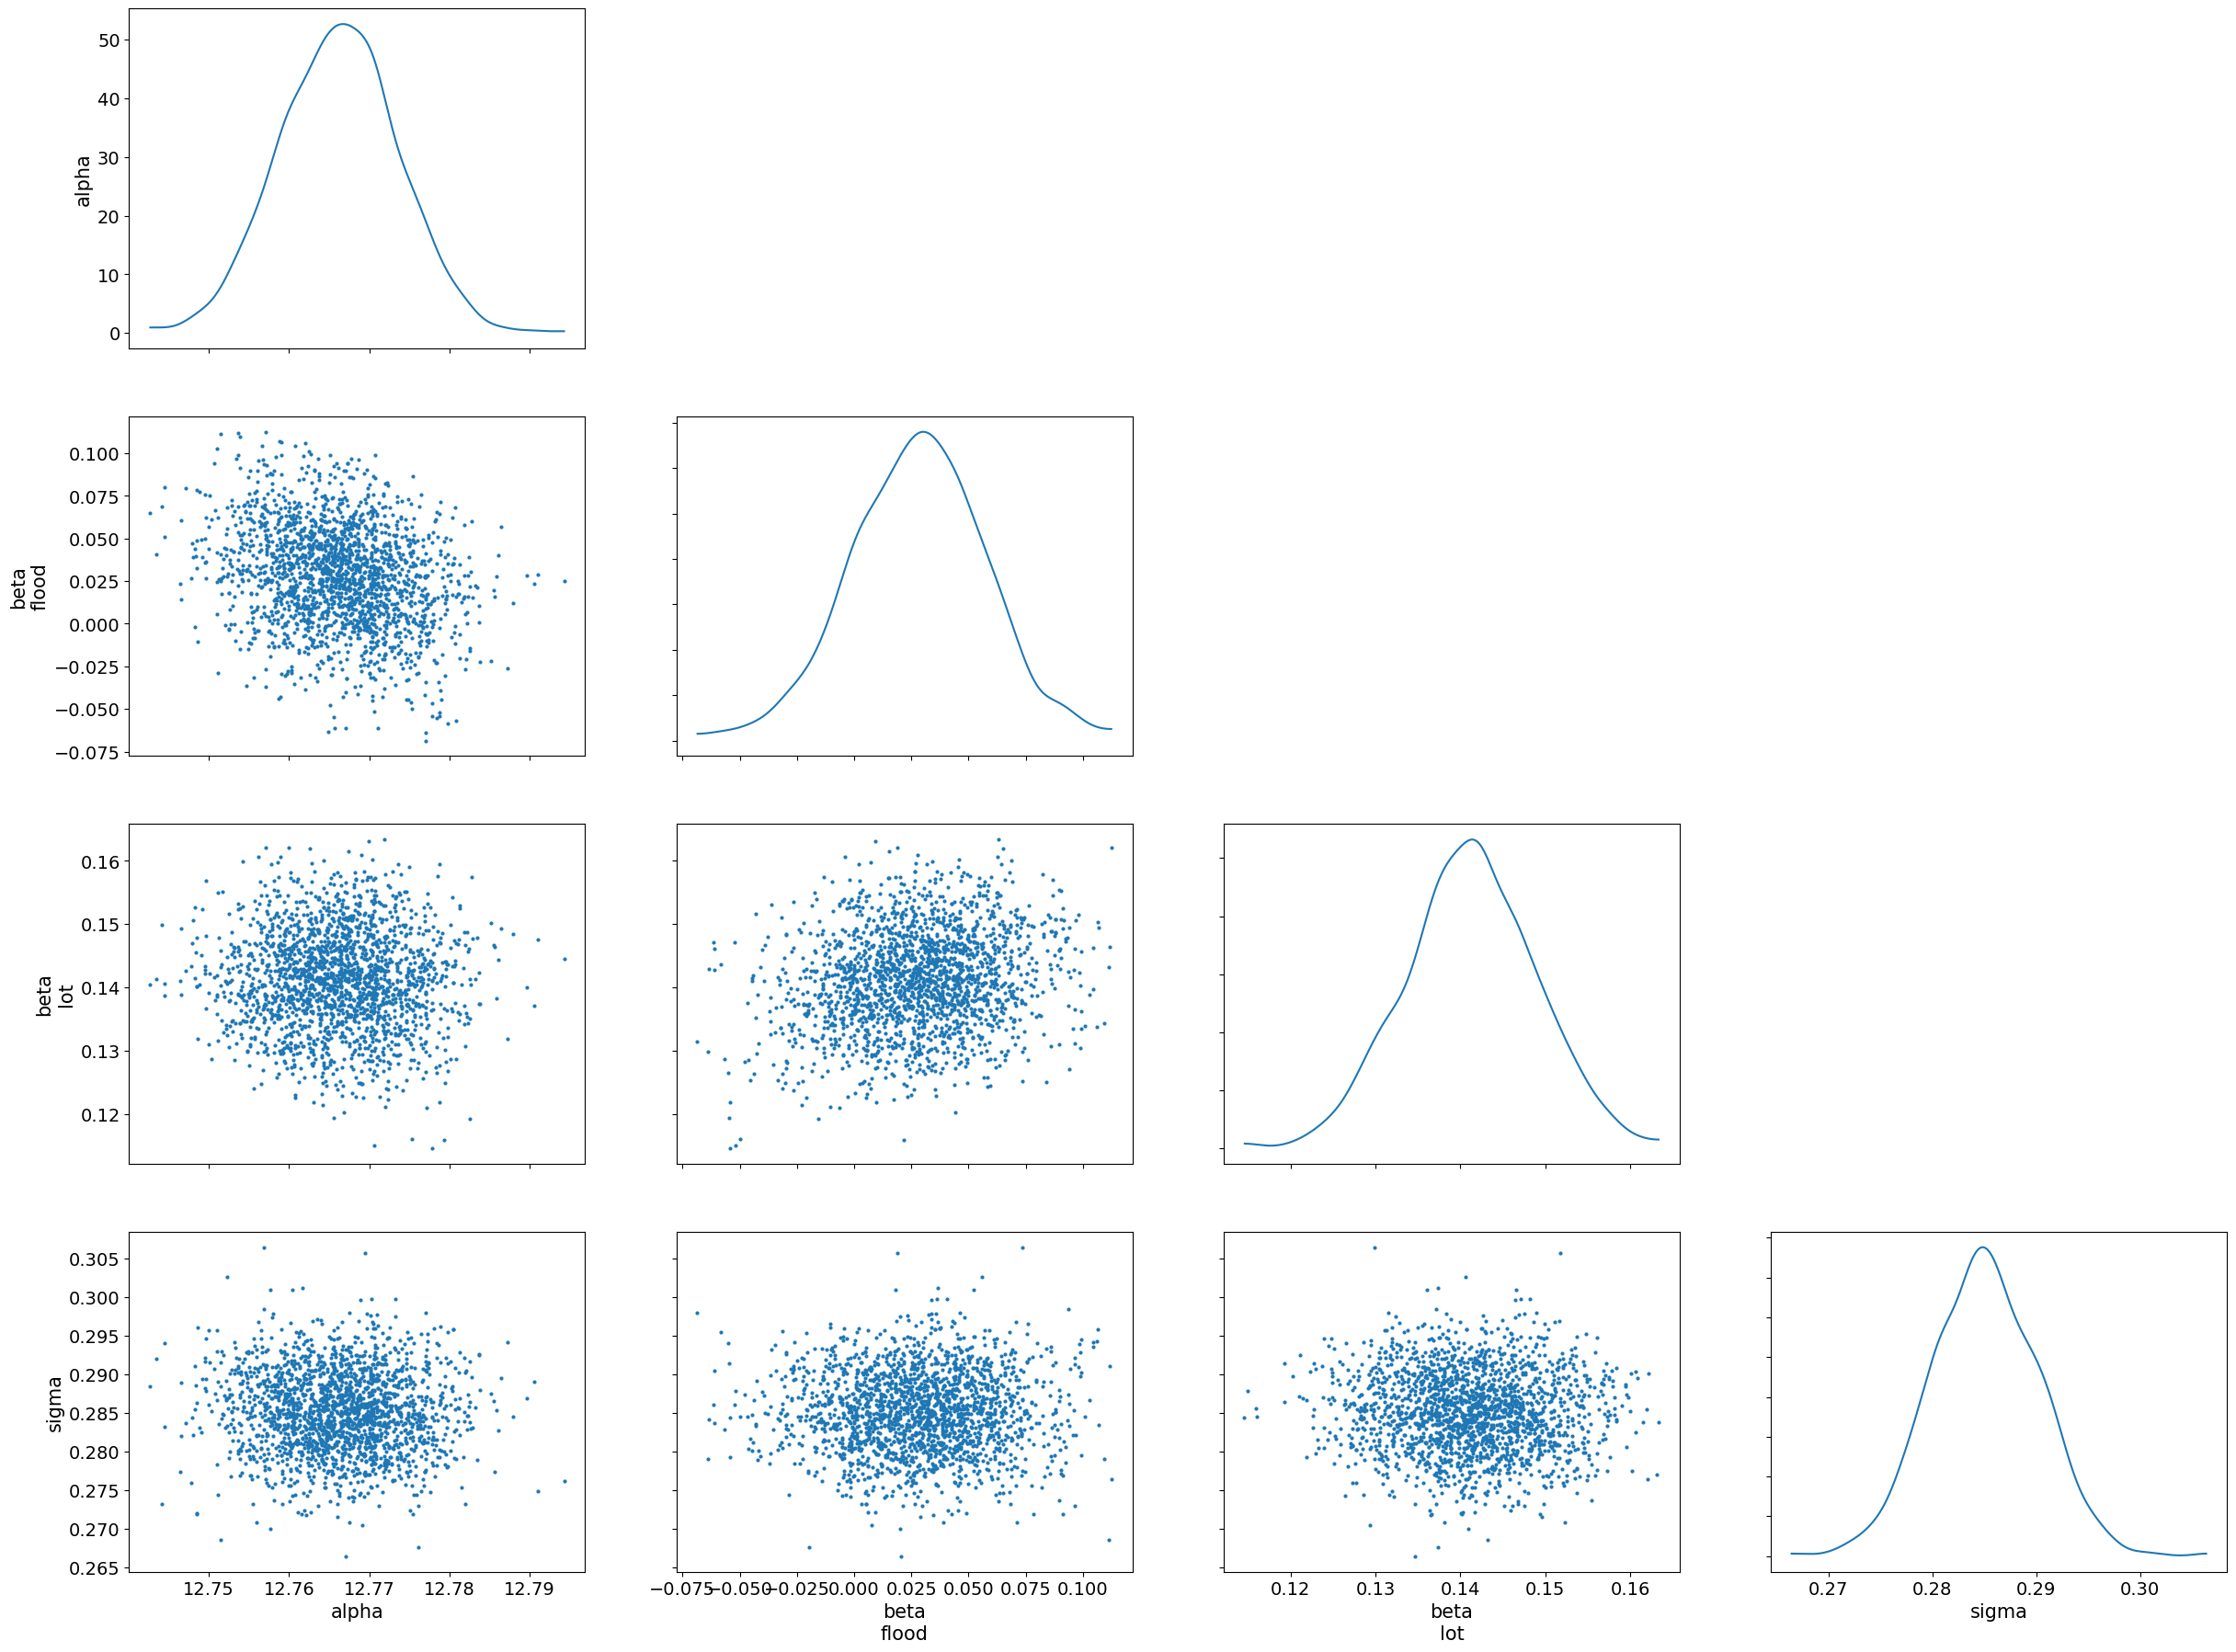

In [128]:
multiple_fit_az = az.from_cmdstanpy(
    posterior=multiple_fit,
    coords={'coef': ['flood', 'lot']},
    dims={'beta': ['coef']},
)
az.plot_pair(multiple_fit_az, var_names=['alpha', 'beta', 'sigma'], marginals=True)
plt.savefig('figures/pairplot_multiple_fit.png', dpi=300)

# 6. Posterior predictive check


Observed min: $38,300
Share of simulated towns with a min that low: 0.0
Observed in-zone sd: 0.3732062805056305
Share of simulated towns with in-zone sd that large: 0.002


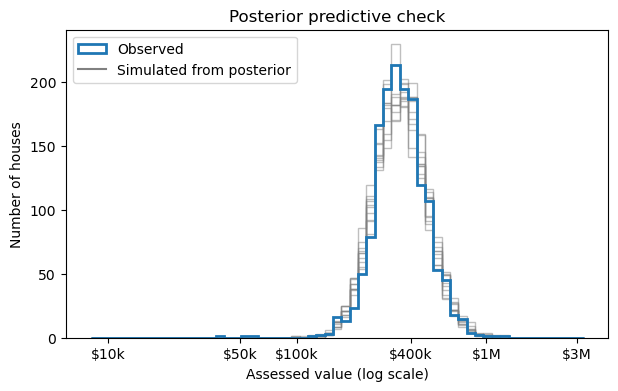

In [ ]:
Y_post = multiple_fit.stan_variable('Y_rep')   # posterior predictive, log scale

plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)
for s in rng.choice(len(Y_post), 10, replace=False):   # CHANGED: seeded rng
    plt.hist(Y_post[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')
plt.plot([], [], color='grey', label='Simulated from posterior')
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Posterior predictive check')
plt.legend()

obs = filtered_montpelier_data['log_value'].values
in_zone = filtered_montpelier_data['in_sfha'].values == 1

# 1. Cheapest house: can the model produce values as low as the real minimum?
sim_min = Y_post.min(axis=1)
print(f"Observed min: ${np.exp(obs.min()):,.0f}")
print(f"Share of simulated towns with a min that low: {(sim_min <= obs.min()).mean()}")

# 2. Spread within the flood zone: does one shared sigma fit the in-zone group?
sim_sd_in = Y_post[:, in_zone].std(axis=1)
print(f"Observed in-zone sd: {obs[in_zone].std()}")
print(f"Share of simulated towns with in-zone sd that large: {(sim_sd_in >= obs[in_zone].std()).mean()}")

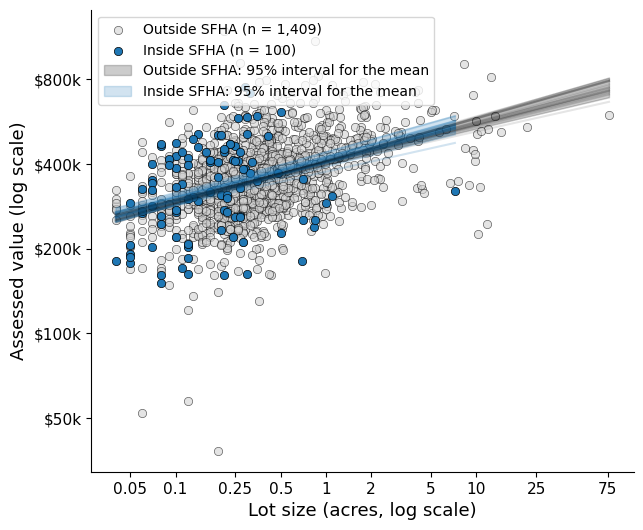

In [140]:
alpha = multiple_fit.stan_variable('alpha')   # shape (S,)
beta = multiple_fit.stan_variable('beta')     # shape (S, 2): [:, 0] flood, [:, 1] lot

def mu_on_grid(log_x, flood):
    """mu = alpha + beta1 * flood + beta2 * (centered log acres), for every draw on a grid."""
    x_lot = log_x - mean_log_acres
    return alpha[:, None] + beta[:, 0:1] * flood + beta[:, 1:2] * x_lot[None, :]   # (S, G)

# each group's line covers only the lot sizes that group actually has
grid_out = np.linspace(log_acres[out_zone].min(), log_acres[out_zone].max(), 200)
grid_in = np.linspace(log_acres[in_zone].min(), log_acres[in_zone].max(), 200)
mu_out = mu_on_grid(grid_out, flood=0)
mu_in = mu_on_grid(grid_in, flood=1)

viz_scatter(title='Posterior regression lines')

# use the same 20 draws for both groups, so each pair of lines comes from one posterior draw
for s in rng.choice(len(alpha), 20, replace=False):
    plt.plot(grid_out, mu_out[s], color='k', alpha=0.1)
    plt.plot(grid_in, mu_in[s], color='tab:blue', alpha=0.2)

for grid, mu, color, label in [(grid_out, mu_out, 'k', 'Outside SFHA'),
                               (grid_in, mu_in, 'tab:blue', 'Inside SFHA')]:
    lo, hi = np.percentile(mu, [2.5, 97.5], axis=0)
    plt.fill_between(grid, lo, hi, color=color, alpha=0.2,
                     label=f'{label}: 95% interval for the mean')

plt.legend(loc='upper left')
plt.savefig('figures/posterior_regression_lines.png', dpi=300)

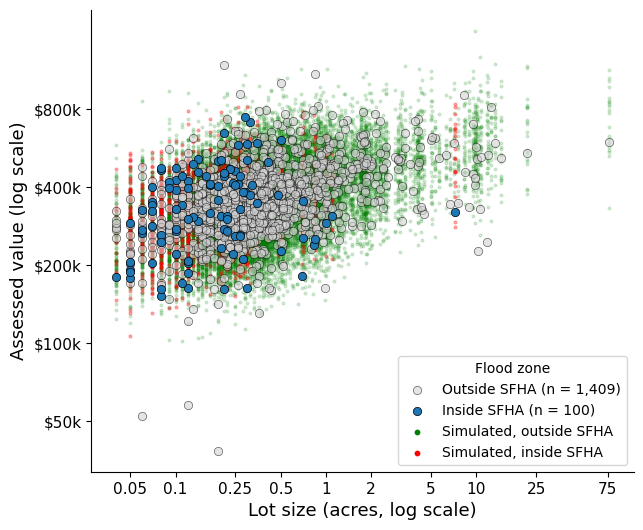

In [152]:
out_sim_color, in_sim_color = 'green', 'red'

Y_rep_multiple = multiple_fit.stan_variable('Y_rep')
viz_scatter(title='Posterior predictive datasets')
for s in rng.choice(len(Y_rep_multiple), 20, replace=False):
    plt.scatter(log_acres[~in_zone], Y_rep_multiple[s, ~in_zone], color=out_sim_color, s=4, alpha=0.15, zorder=-10)
    plt.scatter(log_acres[in_zone], Y_rep_multiple[s, in_zone], color=in_sim_color, s=4, alpha=0.3, zorder=-9)
plt.scatter([], [], color=out_sim_color, s=10, label='Simulated, outside SFHA')
plt.scatter([], [], color=in_sim_color, s=10, label='Simulated, inside SFHA')
plt.legend(loc='lower right', fontsize=10, title='Flood zone')
plt.savefig('figures/posterior_predictive_datasets.png', dpi=300)